
# STEP 1: Import all required libraries

In [26]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)


# Load telecom churn dataset

In [27]:
df = pd.read_csv('churn_ds.csv')  

print("="*60)
print("TELECOM CUSTOMER CHURN DATASET")
print("="*60)
print(f"Dataset shape: {df.shape} (rows, columns)")
print(f"\nFirst 5 rows:")
df.head()


TELECOM CUSTOMER CHURN DATASET
Dataset shape: (10000, 14) (rows, columns)

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Check dataset information

In [28]:

print("\n" + "="*60)
print("DATASET INFO")
print("="*60)
print(df.info())


DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB
None


# Check for missing values

In [29]:

print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)
print(df.isnull().sum())



MISSING VALUES CHECK
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


# Drop Unnecessary Columns

In [30]:

print("="*60)
print("STEP 4: DROPPING UNNECESSARY COLUMNS")
print("="*60)

# Columns to drop (RowNumber, CustomerId, Surname are useless for prediction)
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']

# Check which columns exist in dataset
existing_drop = [col for col in columns_to_drop if col in df.columns]
print(f"Columns to drop: {existing_drop}")

# Drop the columns
df = df.drop(columns=existing_drop)

print(f"\n✅ Dropped {len(existing_drop)} columns")
print(f"New dataset shape: {df.shape}")
print(f"\nRemaining columns:")
print(df.columns.tolist())

STEP 4: DROPPING UNNECESSARY COLUMNS
Columns to drop: ['RowNumber', 'CustomerId', 'Surname']

✅ Dropped 3 columns
New dataset shape: (10000, 11)

Remaining columns:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


# Separate Features (X) and Target (y)

In [31]:

print("="*60)
print("STEP 5: FEATURES (X) AND TARGET (Y) SEPARATION")
print("="*60)

# Target column is 'Exited' (1 = customer left, 0 = customer stayed)
X = df.drop('Exited', axis=1)  # Features (input)
y = df['Exited']                # Target (output)

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeature names:")
print(X.columns.tolist())
print(f"\nTarget unique values: {y.unique()}")
print(f"Meaning: 0 = Customer Stayed, 1 = Customer Churned")

STEP 5: FEATURES (X) AND TARGET (Y) SEPARATION
Features (X) shape: (10000, 10)
Target (y) shape: (10000,)

Feature names:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Target unique values: [1 0]
Meaning: 0 = Customer Stayed, 1 = Customer Churned


# Handle Categorical Variables (Geography, Gender)

In [32]:
print("="*60)
print("STEP 6: ONE-HOT ENCODING FOR CATEGORICAL VARIABLES")
print("="*60)

# Find which columns are categorical (text type)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns found: {categorical_cols}")

# Apply one-hot encoding
if categorical_cols:
    print("\nConverting categorical columns to numbers...")
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    print(f"✅ Encoding complete!")
    print(f"New shape after encoding: {X.shape}")
    print(f"\nAll columns now (all are numbers):")
    print(X.columns.tolist())
else:
    print("No categorical columns found.")

STEP 6: ONE-HOT ENCODING FOR CATEGORICAL VARIABLES
Categorical columns found: ['Geography', 'Gender']

Converting categorical columns to numbers...
✅ Encoding complete!
New shape after encoding: (10000, 11)

All columns now (all are numbers):
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


# Scale Numerical Features

In [33]:
print("="*60)
print("STEP 7: SCALING NUMERICAL FEATURES")
print("="*60)

# Identify numerical columns
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
                  'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

# Check which numerical columns exist
existing_numerical = [col for col in numerical_cols if col in X.columns]
print(f"Numerical columns to scale: {existing_numerical}")

# Apply StandardScaler (makes mean=0, standard deviation=1)
scaler = StandardScaler()
X[existing_numerical] = scaler.fit_transform(X[existing_numerical])

print("\n✅ Scaling complete!")
print("Before scaling: Original values had different ranges")
print("After scaling: All values are now standardized (mean≈0, std≈1)")
print("\nSample of scaled data (first 5 rows):")
print(X[existing_numerical].head())

STEP 7: SCALING NUMERICAL FEATURES
Numerical columns to scale: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

✅ Scaling complete!
Before scaling: Original values had different ranges
After scaling: All values are now standardized (mean≈0, std≈1)

Sample of scaled data (first 5 rows):
   CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  \
0    -0.326221  0.293517 -1.041760 -1.225848      -0.911583   0.646092   
1    -0.440036  0.198164 -1.387538  0.117350      -0.911583  -1.547768   
2    -1.536794  0.293517  1.032908  1.333053       2.527057   0.646092   
3     0.501521  0.007457 -1.387538 -1.225848       0.807737  -1.547768   
4     2.063884  0.388871 -1.041760  0.785728      -0.911583   0.646092   

   IsActiveMember  EstimatedSalary  
0        0.970243         0.021886  
1        0.970243         0.216534  
2       -1.030670         0.240687  
3       -1.030670        -0.108918  
4        0.970243   

# Split Data into Train and Test Sets

In [34]:


print("="*60)
print("STEP 8: TRAIN-TEST SPLIT")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set - Churn rate: {y_train.mean():.3f}")
print(f"Testing set - Churn rate: {y_test.mean():.3f}")
print(f"\nInput features for model: {X_train.shape[1]}")

STEP 8: TRAIN-TEST SPLIT
Training set size: 8000 samples (80.0%)
Testing set size: 2000 samples (20.0%)

Training set - Churn rate: 0.204
Testing set - Churn rate: 0.203

Input features for model: 11


# Build ANN Model

In [35]:

print("="*60)
print("STEP 9: BUILDING ANN MODEL")
print("="*60)

model = Sequential([
    # Hidden Layer 1: 64 neurons, ReLU activation
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),  # Prevents overfitting
    
    # Hidden Layer 2: 32 neurons, ReLU activation
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    # Output Layer: 1 neuron, Sigmoid (gives probability between 0-1)
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Model created successfully!")
print("\nModel Architecture:")
model.summary()

STEP 9: BUILDING ANN MODEL
✅ Model created successfully!

Model Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                     │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Model

In [36]:

print("="*60)
print("STEP 14: IMPROVING MODEL WITH CLASS WEIGHTS")
print("="*60)

# Calculate class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"Class weights: {class_weight_dict}")
print("(Giving more importance to churn class during training)")

# Build improved model
model_improved = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_improved.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

# Train with class weights
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_improved = model_improved.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=120,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight_dict,  # This helps with low recall
    verbose=1
)

# Evaluate improved model
y_pred_prob_imp = model_improved.predict(X_test)
y_pred_imp = (y_pred_prob_imp > 0.5).astype(int)

print("\n" + "="*60)
print("IMPROVED MODEL RESULTS")
print("="*60)
print(classification_report(y_test, y_pred_imp, target_names=['Stayed (0)', 'Churned (1)']))

# Confusion Matrix
cm_imp = confusion_matrix(y_test, y_pred_imp)
print("\nConfusion Matrix:")
print(cm_imp)

auc_imp = roc_auc_score(y_test, y_pred_prob_imp)
print(f"\nROC-AUC Score: {auc_imp:.4f}")

STEP 14: IMPROVING MODEL WITH CLASS WEIGHTS
Class weights: {0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}
(Giving more importance to churn class during training)
Epoch 1/120
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6539 - loss: 0.6151 - recall: 0.6664 - val_accuracy: 0.7125 - val_loss: 0.5477 - val_recall: 0.7125
Epoch 2/120
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7184 - loss: 0.5532 - recall: 0.7183 - val_accuracy: 0.7425 - val_loss: 0.4991 - val_recall: 0.7625
Epoch 3/120
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7422 - loss: 0.5263 - recall: 0.7313 - val_accuracy: 0.7688 - val_loss: 0.4738 - val_recall: 0.7469
Epoch 4/120
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7658 - loss: 0.5108 - recall: 0.7405 - val_accuracy: 0.7800 - val_loss: 0.4673 - val_recall: 0.7594
Epoch 5/120
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7706 - loss: 0.4944 - recall: 0.7328 - val_accuracy: 0.7812 - val_loss: 0.4592 

# Evaluate Model Performance

In [37]:


print("="*60)
print("STEP 11: MODEL EVALUATION")
print("="*60)

# Predict on test data
y_pred_prob = model_improved.predict(X_test)  # Probabilities (0-1)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert to 0 or 1


# Classification Report
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Churned (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nCONFUSION MATRIX:")
print(cm)

# ROC-AUC Score
auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC-AUC SCORE: {auc:.4f}")

STEP 11: MODEL EVALUATION
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Stayed (0)       0.93      0.80      0.86      1593
 Churned (1)       0.49      0.76      0.59       407

    accuracy                           0.79      2000
   macro avg       0.71      0.78      0.72      2000
weighted avg       0.84      0.79      0.80      2000


CONFUSION MATRIX:
[[1268  325]
 [  99  308]]

ROC-AUC SCORE: 0.8624


#  Visualize Results

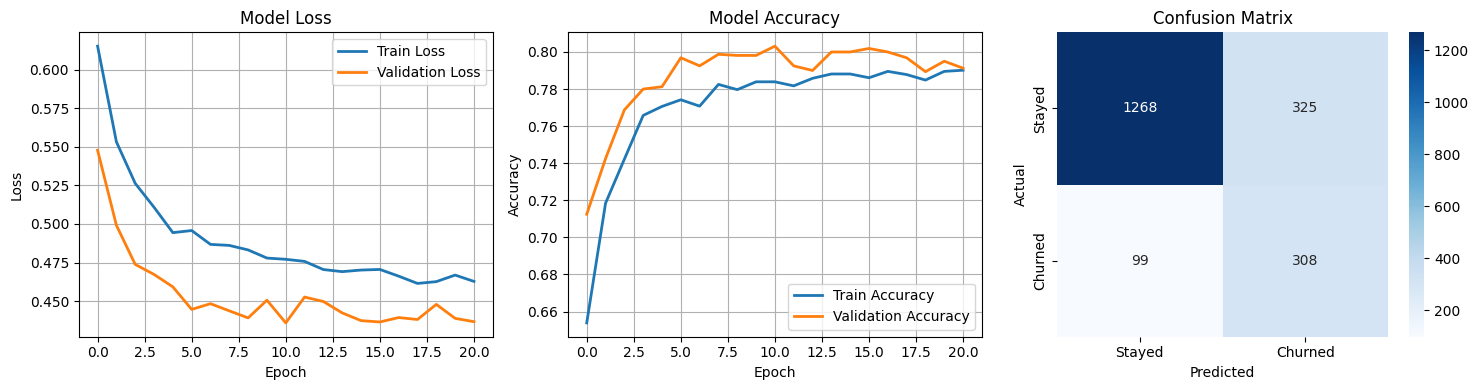

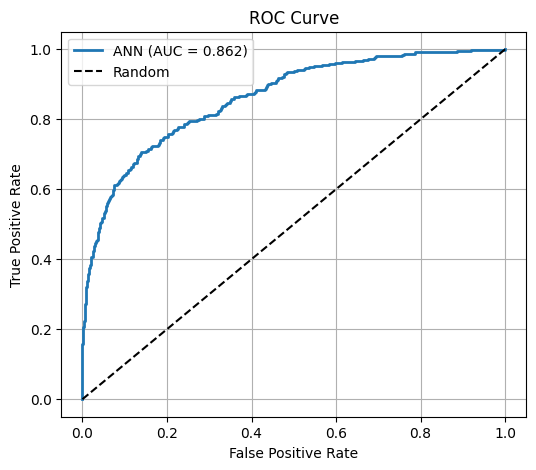

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Training vs Validation Loss
axes[0].plot(history_improved.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_improved.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model Loss')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Training vs Validation Accuracy
axes[1].plot(history_improved.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history_improved.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].legend()
axes[1].grid(True)

# Plot 3: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'], ax=axes[2])
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

# ROC Curve
plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label=f'ANN (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

 # Save Model for Deployment

In [39]:


import joblib

# Save the improved model
model_improved.save('telecom_churn_model.h5')
print("✅ Model saved as 'telecom_churn_model.h5'")

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved as 'scaler.pkl'")

# Save feature names
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')
print("✅ Feature names saved")

# Function to predict new customers
def predict_churn(new_customer_data):
    """
    Predict churn probability for a new customer
    """
    # Scale the data
    new_customer_scaled = scaler.transform(new_customer_data[num_cols])
    new_customer_data[num_cols] = new_customer_scaled
    
    # Make prediction
    churn_prob = model_improved.predict(new_customer_data)
    return churn_prob

print("\n✅ Model ready for deployment!")
print("\n📋 Prediction Function Created:")
print("   Use: predict_churn(your_customer_data)")

✅ Model saved as 'telecom_churn_model.h5'
✅ Scaler saved as 'scaler.pkl'
✅ Feature names saved

✅ Model ready for deployment!

📋 Prediction Function Created:
   Use: predict_churn(your_customer_data)


In [40]:
import joblib
import tensorflow as tf

# Save model (recommended format)
model_improved.save("model.keras")   # ✅ Better than .h5

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save feature names
joblib.dump(X_train.columns.tolist(), "features.pkl")

print("✅ All files saved successfully!")

✅ All files saved successfully!


In [41]:
import joblib
import tensorflow as tf

# Load model
model = tf.keras.models.load_model("model.keras")

# Load scaler
scaler = joblib.load("scaler.pkl")

# Load features
features = joblib.load("features.pkl")

In [42]:
model_improved.save("model.h5")